In [1]:
import os
import sys
from os import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
import json
import argparse
from scipy.optimize import least_squares
import coord_helper as ch
import cord_helper as ch2
import extra_functions as ef
import h5py
import skyfield.api as sf
import importlib
from numpy.linalg import inv
import numbers

BDC is using numpy


In [2]:
day = '10_11'
bits = 1
baseline_idx = 1

config_file_name = f'config_{day}.json'
working_directory = '/project/s/sievers/thomasb/mars_data_24'

In [3]:
with open(f"{working_directory}/{bits}bit/{day}/{config_file_name}", "r") as f:
    config = json.load(f)
    dir_parents = []
    coords = []
    # unpack information from the json file
    # Call get_starting_index for all antennas except reference
    for i, (ant, details) in enumerate(config["antennas"].items()):
        if (i == 0) or (i ==baseline_idx):
            coords.append(details['coordinates'])
            dir_parents.append(details["path"])
    global_start_time = config["correlation"]["start_timestamp"]
    end_t = config["correlation"]["end_timestamp"]
    v_acclen = config["correlation"]["vis_acclen"]
    visibility_window = config["correlation"]["visibility_window"]
    T_SPECTRA = config["correlation"]["point_PFB"] / config["correlation"]["sample_rate"]


ref_coords = coords[0]
v_nchunks = int((visibility_window)/(v_acclen* T_SPECTRA))

context = [visibility_window, T_SPECTRA, v_acclen, v_nchunks, ref_coords]
print(global_start_time)

1699593012


In [4]:
pl = []

with h5py.File(f'{working_directory}/{bits}bit/{day}/vis_selected_bline_{baseline_idx}_{global_start_time}.h5', 'r') as f:
    for p in f:
        pulse_info = []
        pulse_info.append(p)
        pulse_info.append([f[p].attrs['start_time'], f[p].attrs['end_time'], int(f[p].attrs['global_start_time'])])
        pulse_info.append([int(f[p].attrs['sat']), int(f[p].attrs['chan'])])
        pulse_info.append(f[p].attrs['tle_path'])
        pulse_info.append(f[f'/{p}'][:])
        pl.append(pulse_info)

print(pl[0][:4])

['0_1000', [np.float64(1000.0), np.float64(1172.032), 1699593012], [33591, 1850], '/project/s/sievers/mohanagr/OCOMM_TLES/2023/202311/20231110.txt']


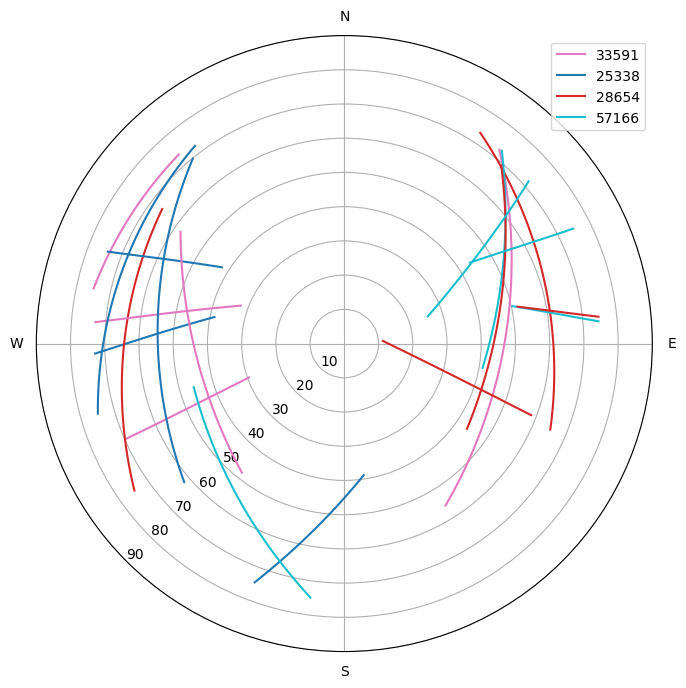

In [5]:
fig = ch.satpass_plotter(pl, coords[1])

In [17]:
importlib.reload(ch)
importlib.reload(ch2)
importlib.reload(ef)

<module 'extra_functions' from '/home/s/sievers/thomasb/albatros_analysis/scripts/orbcomm/fitting/extra_functions.py'>

In [18]:
result = ef.solid_irls_test(coords[1], 0, ef.pred, pl, context, iterations = 4)

time for one delay pred: 0.013739585876464844
time taken pred 0.013884544372558594
time for one delay pred: 0.013536930084228516
time taken pred 0.013638019561767578
time for one delay pred: 0.019993305206298828
time taken pred 0.020102739334106445
time for one delay pred: 0.018028736114501953
time taken pred 0.018139362335205078
time for one delay pred: 0.014166593551635742
time taken pred 0.014262914657592773
time for one delay pred: 0.015229940414428711
time taken pred 0.01534128189086914
time for one delay pred: 0.013379812240600586
time taken pred 0.013479471206665039
time for one delay pred: 0.01226496696472168
time taken pred 0.012356996536254883
time for one delay pred: 0.01213526725769043
time taken pred 0.012224435806274414
time for one delay pred: 0.01752614974975586
time taken pred 0.017638683319091797
time for one delay pred: 0.012089729309082031
time taken pred 0.012175321578979492
time for one delay pred: 0.012468576431274414
time taken pred 0.0125579833984375
time for o

In [19]:
for i in range(len(result)):
    print(result[i])

[ 79.41722016 -90.75889111 183.11798862]
[(1.637795264741726e-05, 1.0596389468386202e-05, -5.809847550608538e-05), (2.308859450295131e-05, 8.840977503895719e-06, -0.0001612389629883637), (9.312953466178442e-06, 1.2523217033523627e-05, 5.031383668097078e-05), (2.8633337478822796e-06, -2.704880085601198e-07, -4.800498655299634e-05), (-6.074697012081742e-07, 5.665430898958134e-08, 1.0556606810041558e-05), (-5.26631936281774e-06, 4.387077260227434e-07, 9.415070007889881e-05), (-8.858933142619208e-08, 9.29711736838558e-09, 1.3479672134053544e-06), (-6.675838903902331e-06, -2.7173730858359564e-06, 0.00011540529416720346), (-1.393700017615629e-06, -5.305167598337922e-07, 2.4006870773973787e-05), (2.4488622329954524e-06, 1.720838317657667e-06, -4.260459800775607e-05), (-7.704107929384918e-07, -5.61313461036485e-07, 1.346713048633319e-05), (-1.3604790183308069e-06, -9.462722270167111e-07, 2.366919531482381e-05)]


In [15]:
fits = []
fits.append(ef.solid_irls(coords[1], 0, ef.pred, pl, context, iterations = 'none'))
for i in range(1,10):
    fits.append(ef.solid_irls(coords[1], 0, ef.pred, pl, context, iterations = i))

time for one delay pred: 0.013374805450439453
time taken pred 0.01358938217163086
time for one delay pred: 0.01350092887878418
time taken pred 0.013602256774902344
time for one delay pred: 0.02049112319946289
time taken pred 0.02059316635131836
time for one delay pred: 0.0179746150970459
time taken pred 0.018072843551635742
time for one delay pred: 0.01435708999633789
time taken pred 0.01445150375366211
time for one delay pred: 0.015342235565185547
time taken pred 0.015437126159667969
time for one delay pred: 0.013530731201171875
time taken pred 0.013622522354125977
time for one delay pred: 0.012253761291503906
time taken pred 0.01234745979309082
time for one delay pred: 0.0121612548828125
time taken pred 0.012249946594238281
time for one delay pred: 0.017445802688598633
time taken pred 0.017539024353027344
time for one delay pred: 0.012200117111206055
time taken pred 0.012285709381103516
time for one delay pred: 0.012227058410644531
time taken pred 0.012315988540649414
time for one de

In [16]:
for i in range(len(fits)):
    print(fits[i])

[ 79.41722084 -90.75887784 182.98070539]
[ 79.41722021 -90.75888519 183.08919368]
[ 79.41722015 -90.7588885  183.12222416]
[ 79.41722016 -90.75889008 183.12418961]
[ 79.41722016 -90.75889111 183.11798862]
[ 79.41722016 -90.75889195 183.11031629]
[ 79.41722015 -90.75889271 183.10262248]
[ 79.41722015 -90.75889342 183.09521862]
[ 79.41722015 -90.75889411 183.08803023]
[ 79.41722014 -90.75889477 183.08107994]


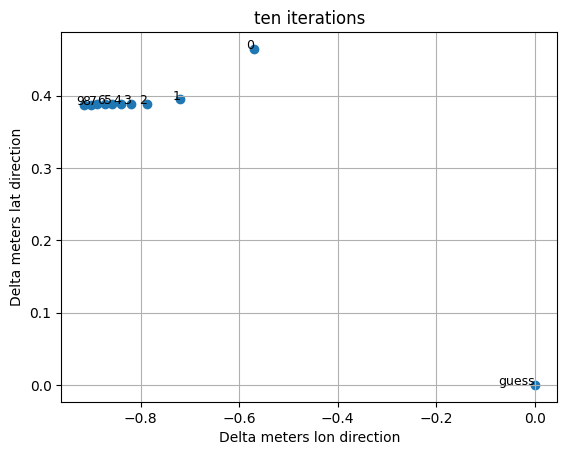

In [17]:
tuple_list = []
for i in range(len(fits)):
    tuple_list.append((f'{i}', fits[i]))

plot = ch.make_coord_plot(coords[1], tuple_list, 'ten iterations')

In [19]:
joint_fits = []
joint_fits.append(ef.joint_irls(coords[1], ef.pred, pl, context, iterations = 'none'))
#joint_fits.append(ef.joint_irls(coords[1], ef.pred, pl, context, iterations = i))




 Starting fit of iteration 0



time for one delay pred: 0.01277470588684082
time taken pred 0.01288747787475586
time for one delay pred: 0.012232303619384766
time taken pred 0.012335777282714844
time for one delay pred: 0.01323699951171875
time taken pred 0.013332366943359375
time for one delay pred: 0.00853419303894043
time taken pred 0.008622407913208008
time for one delay pred: 0.014883995056152344
time taken pred 0.014976739883422852
time for one delay pred: 0.017132997512817383
time taken pred 0.017230987548828125
time for one delay pred: 0.011965513229370117
time taken pred 0.012055158615112305
time for one delay pred: 0.013042211532592773
time taken pred 0.013129711151123047
time for one delay pred: 0.008466005325317383
time taken pred 0.008551836013793945
time for one delay pred: 0.011890649795532227
time taken pred 0.011980295181274414
time for one delay pred: 0.009567499160766602
time taken pred 0.009652853012084961
time for one delay pred: 0.008454322814941406
time taken

In [27]:
joint_fits.append(ef.joint_irls(coords[1], ef.pred, pl, context, iterations = 1))




 Starting fit of iteration 0



time for one delay pred: 0.012241601943969727
time taken pred 0.012366533279418945
time for one delay pred: 0.012232303619384766
time taken pred 0.01235198974609375
time for one delay pred: 0.013498067855834961
time taken pred 0.013606548309326172
time for one delay pred: 0.008462905883789062
time taken pred 0.008553504943847656
time for one delay pred: 0.014240026473999023
time taken pred 0.01433253288269043
time for one delay pred: 0.01720452308654785
time taken pred 0.017299652099609375
time for one delay pred: 0.01196599006652832
time taken pred 0.012056827545166016
time for one delay pred: 0.013197183609008789
time taken pred 0.013286590576171875
time for one delay pred: 0.008547782897949219
time taken pred 0.008633613586425781
time for one delay pred: 0.0118560791015625
time taken pred 0.01194453239440918
time for one delay pred: 0.009679317474365234
time taken pred 0.009765625
time for one delay pred: 0.008414268493652344
time taken pred 0.0085

[ 79.41721848 -90.75872502 183.51076468]
[ 79.41723874 -90.75876639 181.15130772]


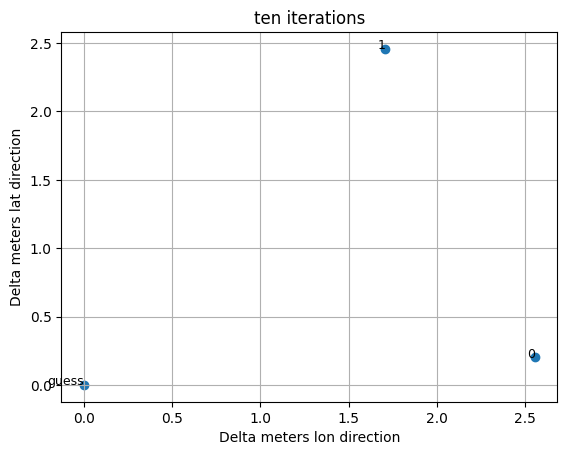

In [32]:
for i in range(len(joint_fits)):
    print(joint_fits[i][:3])

tuple_list = []
for i in range(len(joint_fits)):
    tuple_list.append((f'{i}', joint_fits[i]))

plot = ch.make_coord_plot(coords[1], tuple_list, 'ten iterations')

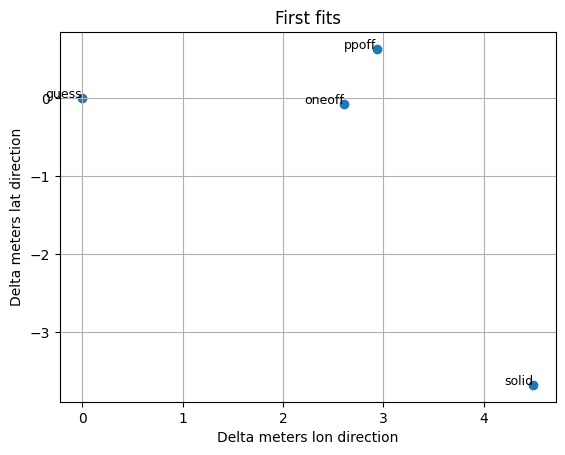

In [27]:
fig = ch.make_coord_plot(coords[1], tuple_list, 'First fits')

In [70]:
ds = ch.fit_ds_all(solid, ch.pred, pl, context)

time taken for one prediction 0.014196634292602539
time taken for one prediction 0.013453245162963867
time taken for one prediction 0.013193368911743164
time taken for one prediction 0.01315164566040039
time taken for one prediction 0.013200759887695312
time taken for one prediction 0.013089895248413086
time taken for one prediction 0.013300180435180664
time taken for one prediction 0.013020038604736328
time taken for one prediction 0.013151407241821289
time taken for one prediction 0.013346433639526367
time taken for one prediction 0.013834714889526367
time taken for one prediction 0.013999462127685547
time taken for one prediction 0.013990163803100586
time taken for one prediction 0.013844728469848633
time taken for one prediction 0.01389455795288086
time taken for one prediction 0.013894319534301758
time taken for one prediction 0.014011144638061523
time taken for one prediction 0.013907194137573242
time taken for one prediction 0.014025211334228516
time taken for one prediction 0.0

In [71]:
solid2 = ch.fit_given_offsets(coords[1], ch.pred, ds, pl, context)[0]
solid3 = ch.fit_given_offsets(solid, ch.pred, ds, pl, context)[0]

time taken for one prediction 0.013810396194458008
time taken for one prediction 0.014114856719970703
time taken for one prediction 0.0069425106048583984
time taken for one prediction 0.0069849491119384766
time taken for one prediction 0.009336709976196289
time taken for one prediction 0.010097980499267578
time taken for one prediction 0.01058650016784668
time taken for one prediction 0.009371757507324219
time taken for one prediction 0.011368751525878906
time taken for one prediction 0.009310007095336914
time taken for one prediction 0.011327028274536133
time taken for one prediction 0.012793779373168945
time taken for one prediction 0.01181793212890625
time taken for one prediction 0.011402606964111328
time taken for one prediction 0.017885208129882812
time taken for one prediction 0.011393070220947266
time taken for one prediction 0.01384592056274414
time taken for one prediction 0.01557302474975586
time taken for one prediction 0.01981329917907715
time taken for one prediction 0.01

In [72]:
tuple_list_2 = [('s1', solid), ('s2', solid2), ('s3', solid3)]

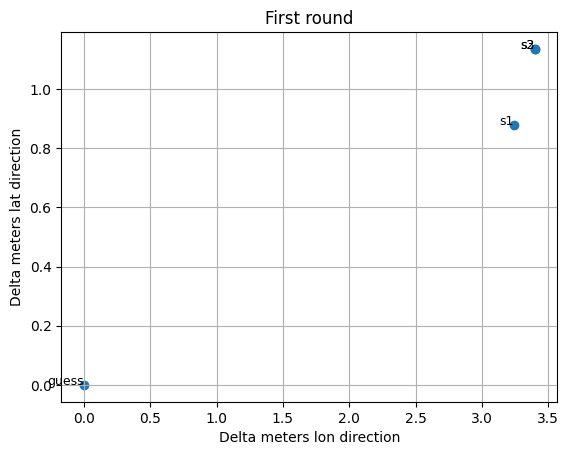

In [73]:
fig = ch.make_coord_plot(coords[1], tuple_list_2, 'First round')

In [74]:
cov = ch.fit_cov(solid, ch.pred, pl, context)

time taken for one prediction 0.013889789581298828
time taken for one prediction 0.01436305046081543
time taken for one prediction 0.006948709487915039
time taken for one prediction 0.007087230682373047
time taken for one prediction 0.009275197982788086
time taken for one prediction 0.010046243667602539
time taken for one prediction 0.010611772537231445
time taken for one prediction 0.00917506217956543
time taken for one prediction 0.011430740356445312
time taken for one prediction 0.009496450424194336
time taken for one prediction 0.011430025100708008
time taken for one prediction 0.012427568435668945
time taken for one prediction 0.011923074722290039
time taken for one prediction 0.011420249938964844
time taken for one prediction 0.01826190948486328
time taken for one prediction 0.011436223983764648
time taken for one prediction 0.01434636116027832
time taken for one prediction 0.015752792358398438
time taken for one prediction 0.020255565643310547
time taken for one prediction 0.016

time taken for one prediction 0.01214289665222168
time taken for one prediction 0.011557579040527344
time taken for one prediction 0.01813530921936035
time taken for one prediction 0.011497735977172852
time taken for one prediction 0.014157533645629883
time taken for one prediction 0.015729188919067383
time taken for one prediction 0.019953012466430664
time taken for one prediction 0.016260385513305664
time taken for one prediction 0.02193307876586914
time taken for one prediction 0.013781547546386719
time taken for one prediction 0.012906789779663086
time taken for one prediction 0.013957500457763672
time taken for one prediction 0.006826877593994141
time taken for one prediction 0.006976604461669922
time taken for one prediction 0.00910639762878418
time taken for one prediction 0.009930133819580078
time taken for one prediction 0.010532140731811523
time taken for one prediction 0.009136438369750977
time taken for one prediction 0.011415958404541016
time taken for one prediction 0.009

In [75]:
print(cov[0])
tuple_list_3 = [('s1', solid), ('ppoff', ppoff), ('cov', cov[0])]

[ 79.41720098 -90.75889116 183.90471545]


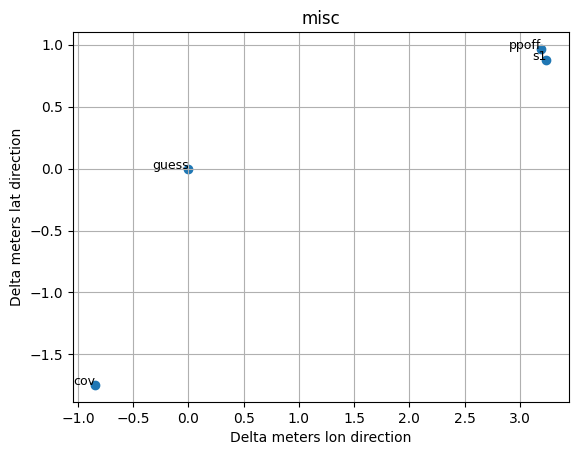

In [76]:
fig = ch.make_coord_plot(coords[1], tuple_list_3, 'misc')